# RuCoLA: сравнение подходов к классификации лингвистической приемлемости

**Задача:** бинарная классификация предложений (грамматически/семантически приемлемо или нет).

**Данные:** [RuCoLA](https://github.com/RussianNLP/RuCoLA)
- обучение: `in_domain_train.csv` (разбиваем на train/val)
- тест: `in_domain_dev.csv`

**Модели:**
1. Fine-tuning **ruBERT** (Encoder, классификация)
2. **Few-/Zero-shot** с **ruGPT3**
3. Fine-tuning **ruT5** (Seq2Seq)



In [27]:
%%capture
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas matplotlib seaborn razdel


In [33]:
import os
import random
import warnings
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from razdel import tokenize
from sklearn.metrics import accuracy_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from tqdm.auto import tqdm, trange
from transformers import (
    BertForSequenceClassification,
    BertTokenizer,
    DataCollatorForSeq2Seq,
    DataCollatorWithPadding,
    GPT2LMHeadModel,
    GPT2Tokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    T5ForConditionalGeneration,
    T5Tokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

RUBERT_MODEL = "sberbank-ai/ruBert-base"
RUGPT3_MODEL = "sberbank-ai/rugpt3small_based_on_gpt2"
RUT5_MODEL = "sberbank-ai/ruT5-base"

POS_LABEL = "yes"
NEG_LABEL = "no"
POS_LABEL_RU = "да"
NEG_LABEL_RU = "нет"

DATA_URL = "https://raw.githubusercontent.com/RussianNLP/RuCoLA/main/data"
RESULTS = {}


Device: cuda


## 1. Загрузка и подготовка данных


In [29]:
train_full = pd.read_csv(f"{DATA_URL}/in_domain_train.csv")
test_df = pd.read_csv(f"{DATA_URL}/in_domain_dev.csv")

print("Train (full):", train_full.shape)
print("Test (in_domain_dev):", test_df.shape)
print(train_full.head())
print("\nClass balance (train):")
print(train_full["acceptable"].value_counts(normalize=True))


Train (full): (7869, 5)
Test (in_domain_dev): (983, 5)
   id                                           sentence  acceptable  \
0   0  Вдруг решетка беззвучно поехала в сторону, и н...           1   
1   1                       Этим летом не никуда ездили.           0   
2   2  Только Иван выразил какую бы то ни было готовн...           1   
3   3  Теперь ты видишь собственными глазами, как тут...           1   
4   4    На поверку вся теория оказалась полной чепухой.           1   

  error_type detailed_source  
0          0   Paducheva2004  
1     Syntax         Rusgram  
2          0   Paducheva2013  
3          0   Paducheva2010  
4          0   Paducheva2010  

Class balance (train):
acceptable
1    0.745203
0    0.254797
Name: proportion, dtype: float64


In [30]:
train_df, val_df = train_test_split(
    train_full,
    test_size=0.1,
    random_state=SEED,
    stratify=train_full["acceptable"],
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

train_ds = Dataset.from_pandas(train_df[["sentence", "acceptable"]], preserve_index=False)
val_ds = Dataset.from_pandas(val_df[["sentence", "acceptable"]], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[["sentence", "acceptable"]], preserve_index=False)

splits = DatasetDict(train=train_ds, val=val_ds, test=test_ds)
splits


Train: 7082, Val: 787, Test: 983


DatasetDict({
    train: Dataset({
        features: ['sentence', 'acceptable'],
        num_rows: 7082
    })
    val: Dataset({
        features: ['sentence', 'acceptable'],
        num_rows: 787
    })
    test: Dataset({
        features: ['sentence', 'acceptable'],
        num_rows: 983
    })
})

In [31]:
def compute_cls_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
    }


def evaluate_predictions(y_true, y_pred, name):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    RESULTS[name] = metrics
    print(f"{name}: accuracy={metrics['accuracy']:.4f}, mcc={metrics['mcc']:.4f}")
    return metrics


## 2. Fine-tuning ruBERT

Подход как в семинаре по BERT и в [finetune_mlm.py](https://github.com/RussianNLP/RuCoLA/blob/main/baselines/finetune_mlm.py):
- `BertTokenizer` + `BertForSequenceClassification`
- `Trainer` с метриками Accuracy и MCC


In [34]:
rubert_tokenizer = BertTokenizer.from_pretrained(RUBERT_MODEL)


def preprocess_bert(examples):
    out = rubert_tokenizer(examples["sentence"], truncation=True, max_length=128)
    out["labels"] = examples["acceptable"]
    out["length"] = [len(list(tokenize(s))) for s in examples["sentence"]]
    return out


tokenized_bert = splits.map(preprocess_bert, batched=True, remove_columns=["sentence"])
bert_collator = DataCollatorWithPadding(rubert_tokenizer, pad_to_multiple_of=8)

rubert_model = BertForSequenceClassification.from_pretrained(RUBERT_MODEL, num_labels=2)
if torch.cuda.is_available():
    rubert_model.cuda()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 66290.72it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archit

In [10]:
bert_args = TrainingArguments(
    output_dir="checkpoints/rubert",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_mcc",
    greater_is_better=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

bert_trainer = Trainer(
    model=rubert_model,
    args=bert_args,
    train_dataset=tokenized_bert["train"],
    eval_dataset=tokenized_bert["val"],
    data_collator=bert_collator,
    compute_metrics=compute_cls_metrics,
)

bert_trainer.train()
val_bert = bert_trainer.evaluate(tokenized_bert["val"])
print("Validation:", val_bert)


Epoch,Training Loss,Validation Loss,Accuracy,Mcc
1,0.461045,0.457788,0.787802,0.398296
2,0.294167,0.509932,0.794155,0.410208
3,0.194273,0.712787,0.809403,0.458217


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]


Training Loss,Validation Loss,Epoch,Accuracy,Mcc
0.194273,0.712787,3,0.809403,0.458217


Validation: {'eval_loss': 0.7127870917320251, 'eval_accuracy': 0.8094027954256671, 'eval_mcc': 0.4582167316083459}


In [11]:
bert_test = bert_trainer.predict(tokenized_bert["test"])
bert_preds = np.argmax(bert_test.predictions, axis=-1)
evaluate_predictions(test_df["acceptable"].tolist(), bert_preds.tolist(), "ruBERT (test)")


ruBERT (test): accuracy=0.7904, mcc=0.3845


{'accuracy': 0.7904374364191251, 'mcc': 0.3845415317551291}

### 2.1 (опционально) Ручной цикл обучения — как в семинаре по BERT

Ниже показан альтернативный training loop из семинара; основные результаты берём из `Trainer` выше.


In [14]:
from torch.utils.data import DataLoader


class BertTorchDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"]),
            "attention_mask": torch.tensor(item["attention_mask"]),
            "labels": torch.tensor(item["labels"]),
        }

from torch.nn.utils.rnn import pad_sequence

def collate(batch):
    input_ids = [x["input_ids"] for x in batch]
    attention_mask = [x["attention_mask"] for x in batch]
    labels = torch.stack([x["labels"] for x in batch])

    # Паддим до максимальной длины в батче
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


demo_model = BertForSequenceClassification.from_pretrained(RUBERT_MODEL, num_labels=2).to(DEVICE)
demo_opt = AdamW(demo_model.parameters(), lr=1e-5)

demo_train = BertTorchDataset(
    tokenized_bert["train"].select(range(min(512, len(tokenized_bert["train"]))))
)
demo_val = BertTorchDataset(
    tokenized_bert["val"].select(range(min(128, len(tokenized_bert["val"]))))
)
train_loader = DataLoader(demo_train, batch_size=8, shuffle=True, collate_fn=collate)
val_loader = DataLoader(demo_val, batch_size=16, collate_fn=collate)

losses = []
for epoch in trange(1, desc="Manual BERT demo"):
    demo_model.train()
    pbar = tqdm(train_loader, leave=False)
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = demo_model(**batch)
        out.loss.backward()
        demo_opt.step()
        demo_opt.zero_grad()
        losses.append(out.loss.item())
        pbar.set_description(f"loss={np.mean(losses[-50:]):.3f}")

    demo_model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = demo_model(**batch)
            preds.extend(out.logits.argmax(1).cpu().tolist())
            targets.extend(batch["labels"].cpu().tolist())
    print(f"Demo manual loop val accuracy: {accuracy_score(targets, preds):.4f}")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 49750.64it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archit

Demo manual loop val accuracy: 0.7344


## 3. Few-/Zero-shot с ruGPT3

Используем **ruGPT3** как decoder-only LM:
- строим промпт с примерами (0, 1, 2, 4 shot)
- сравниваем log-likelihood продолжений « да» и « нет»
- перебираем несколько шаблонов затравок


In [35]:
gpt_tokenizer = GPT2Tokenizer.from_pretrained(RUGPT3_MODEL)
gpt_model = GPT2LMHeadModel.from_pretrained(RUGPT3_MODEL)
gpt_model.eval().to(DEVICE)
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

LABEL_TO_TEXT = {1: POS_LABEL_RU, 0: NEG_LABEL_RU}
TEXT_TO_LABEL = {POS_LABEL_RU: 1, NEG_LABEL_RU: 0, "yes": 1, "no": 0}


def sample_few_shot_examples(n_shots, seed=SEED):
    if n_shots == 0:
        return []
    pos = train_df[train_df["acceptable"] == 1].sample(
        n=max(1, n_shots // 2 + n_shots % 2), random_state=seed
    )
    neg = train_df[train_df["acceptable"] == 0].sample(n=n_shots // 2, random_state=seed + 1)
    examples = pd.concat([pos, neg]).sample(frac=1, random_state=seed)
    return examples.to_dict("records")


PROMPT_TEMPLATES = {
    "simple": (
        'Определи, грамматически ли правильно предложение. Ответь "да" или "нет".\n'
        "{examples}"
        "Предложение: {sentence}\nОтвет:"
    ),
    "linguistic": (
        "Задача: лингвистическая приемлемость (CoLA).\n"
        "Приемлемое предложение звучит естественно для носителя русского языка.\n"
        "{examples}"
        "Предложение: {sentence}\nПриемлемо (да/нет):"
    ),
    "instruction": (
        'Ты — лингвист. Классифицируй предложение как грамматически корректное ("да") '
        'или некорректное ("нет").\n'
        "{examples}"
        'Предложение: "{sentence}"\nОтвет:'
    ),
}


def format_examples(examples):
    if not examples:
        return ""
    lines = []
    for ex in examples:
        label = LABEL_TO_TEXT[ex["acceptable"]]
        lines.append(f"Предложение: {ex['sentence']}\nОтвет: {label}\n")
    return "\n".join(lines) + "\n"


def build_prompt(template_name, sentence, examples):
    return PROMPT_TEMPLATES[template_name].format(
        examples=format_examples(examples),
        sentence=sentence,
    )


@torch.no_grad()
def gpt_classify_by_likelihood(prompt, labels=(f" {POS_LABEL_RU}", f" {NEG_LABEL_RU}")):
    best_label, best_score = None, -1e18
    for label_text in labels:
        full = prompt + label_text
        enc = gpt_tokenizer(full, return_tensors="pt").to(DEVICE)
        input_ids = enc["input_ids"]
        prompt_ids = gpt_tokenizer(prompt, return_tensors="pt")["input_ids"]
        start = prompt_ids.shape[1]
        outputs = gpt_model(input_ids)
        log_probs = torch.log_softmax(outputs.logits, dim=-1)
        score = 0.0
        for i in range(start, input_ids.shape[1]):
            token_id = input_ids[0, i]
            score += log_probs[0, i - 1, token_id].item()
        if score > best_score:
            best_score = score
            best_label = label_text.strip()
    return TEXT_TO_LABEL.get(best_label, 0)


def eval_gpt_setting(template_name, n_shots, max_samples=None):
    examples_pool = sample_few_shot_examples(n_shots)
    texts = test_df["sentence"].tolist()
    labels = test_df["acceptable"].tolist()
    if max_samples is not None:
        texts = texts[:max_samples]
        labels = labels[:max_samples]

    preds = []
    for sent in tqdm(texts, desc=f"{template_name}, {n_shots}-shot", leave=False):
        prompt = build_prompt(template_name, sent, examples_pool)
        preds.append(gpt_classify_by_likelihood(prompt))

    name = f"ruGPT3 | {template_name} | {n_shots}-shot"
    return evaluate_predictions(labels, preds, name)


Loading weights: 100%|██████████| 149/149 [00:00<00:00, 49454.09it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
# Полная оценка на test; для ускорения на CPU можно поставить max_samples=200
GPT_MAX_SAMPLES = None  # None = весь in_domain_dev

gpt_results = []
for template in PROMPT_TEMPLATES:
    for n_shots in [0, 1, 2, 4]:
        metrics = eval_gpt_setting(template, n_shots, max_samples=GPT_MAX_SAMPLES)
        gpt_results.append({"template": template, "n_shots": n_shots, **metrics})

gpt_results_df = pd.DataFrame(gpt_results)
gpt_results_df.sort_values("mcc", ascending=False)


ruGPT3 | simple | 0-shot: accuracy=0.6938, mcc=-0.0212


ruGPT3 | simple | 1-shot: accuracy=0.6785, mcc=-0.0364


ruGPT3 | simple | 2-shot: accuracy=0.3642, mcc=0.0402


ruGPT3 | simple | 4-shot: accuracy=0.2899, mcc=-0.0281


ruGPT3 | linguistic | 0-shot: accuracy=0.5432, mcc=0.0872


...

ruGPT3 | instruction | 0-shot: accuracy=0.7396, mcc=-0.0269


ruGPT3 | instruction | 1-shot: accuracy=0.6877, mcc=-0.0633


ruGPT3 | instruction | 2-shot: accuracy=0.2798, mcc=0.0104


ruGPT3 | instruction | 4-shot: accuracy=0.2584, mcc=0.0373


,template,n_shots,accuracy,mcc
4,linguistic,0,0.543235,0.087249
5,linguistic,1,0.572737,0.060816
2,simple,2,0.364191,0.040246
11,instruction,4,0.258393,0.037330
6,linguistic,2,0.314344,0.012733
10,instruction,2,0.279756,0.010436
0,simple,0,0.693795,-0.021168
7,linguistic,4,0.372330,-0.023490
8,instruction,0,0.739573,-0.026900
3,simple,4,0.289929,-0.028114


## 4. Fine-tuning ruT5

Seq2Seq-подход из [finetune_t5.py](https://github.com/RussianNLP/RuCoLA/blob/main/baselines/finetune_t5.py) и T5-seminar:
- вход: предложение
- выход: `yes` / `no`


In [17]:
t5_tokenizer = T5Tokenizer.from_pretrained(RUT5_MODEL)


def preprocess_t5(examples):
    model_inputs = t5_tokenizer(examples["sentence"], max_length=128, truncation=True)
    labels = [POS_LABEL if x == 1 else NEG_LABEL for x in examples["acceptable"]]
    model_inputs["labels"] = t5_tokenizer(labels, max_length=8, truncation=True).input_ids
    model_inputs["length"] = [len(list(tokenize(s))) for s in examples["sentence"]]
    return model_inputs


tokenized_t5 = splits.map(preprocess_t5, batched=True, remove_columns=["sentence"])
t5_collator = DataCollatorForSeq2Seq(t5_tokenizer, pad_to_multiple_of=8)


def compute_t5_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    decoded_preds = t5_tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, t5_tokenizer.pad_token_id)
    decoded_labels = t5_tokenizer.batch_decode(labels, skip_special_tokens=True)
    y_pred = [1 if p.strip() == POS_LABEL else 0 for p in decoded_preds]
    y_true = [1 if l.strip() == POS_LABEL else 0 for l in decoded_labels]
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }


t5_model = T5ForConditionalGeneration.from_pretrained(RUT5_MODEL)


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 16142.45it/s]


In [23]:
t5_args = Seq2SeqTrainingArguments(
    output_dir="checkpoints/rut5",
    eval_strategy="epoch",          # было evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_mcc",
    greater_is_better=True,
    predict_with_generate=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-4,
    weight_decay=0.0,
    lr_scheduler_type="constant",
    optim="adafactor",
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_args,
    train_dataset=tokenized_t5["train"],
    eval_dataset=tokenized_t5["val"],
    data_collator=t5_collator,
    compute_metrics=compute_t5_metrics,
)

t5_trainer.train()
print("Validation:", t5_trainer.evaluate(tokenized_t5["val"]))


Epoch,Training Loss,Validation Loss,Accuracy,Mcc
1,No log,0.427479,0.655654,0.240816
2,0.120210,0.360444,0.750953,0.321717
3,0.067012,0.537255,0.761118,0.309443
4,0.057464,0.369378,0.743329,0.294212
5,0.086457,0.437882,0.730623,0.356409


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training Loss,Validation Loss,Epoch,Accuracy,Mcc
0.086457,0.437882,5,0.730623,0.356409


Validation: {'eval_loss': 0.43788185715675354, 'eval_accuracy': 0.7306226175349428, 'eval_mcc': 0.35640903431837767}


In [24]:
t5_test = t5_trainer.predict(tokenized_t5["test"], max_length=10)
decoded = t5_tokenizer.batch_decode(t5_test.predictions, skip_special_tokens=True)
t5_preds = [1 if p.strip() == POS_LABEL else 0 for p in decoded]
evaluate_predictions(test_df["acceptable"].tolist(), t5_preds, "ruT5 (test)")


ruT5 (test): accuracy=0.7304, mcc=0.3461


{'accuracy': 0.7304170905391658, 'mcc': 0.3461145851706329}

## 5. Сравнение результатов


In [25]:
summary_rows = []

summary_rows.append({"model": "ruBERT", "setting": "fine-tune", **RESULTS["ruBERT (test)"]})
summary_rows.append({"model": "ruT5", "setting": "fine-tune", **RESULTS["ruT5 (test)"]})

best_gpt = gpt_results_df.iloc[gpt_results_df["mcc"].argmax()]
summary_rows.append(
    {
        "model": "ruGPT3",
        "setting": f"best: {best_gpt['template']}, {int(best_gpt['n_shots'])}-shot",
        "accuracy": best_gpt["accuracy"],
        "mcc": best_gpt["mcc"],
    }
)
summary_rows.append(
    {
        "model": "ruGPT3",
        "setting": "mean over all prompts/shots",
        "accuracy": gpt_results_df["accuracy"].mean(),
        "mcc": gpt_results_df["mcc"].mean(),
    }
)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("mcc", ascending=False).reset_index(drop=True)
summary_df


,model,setting,accuracy,mcc
0,ruBERT,fine-tune,0.790437,0.384542
1,ruT5,fine-tune,0.730417,0.346115
2,ruGPT3,"best: linguistic, 0-shot",0.543235,0.087249
3,ruGPT3,mean over all prompts/shots,0.482876,0.004116


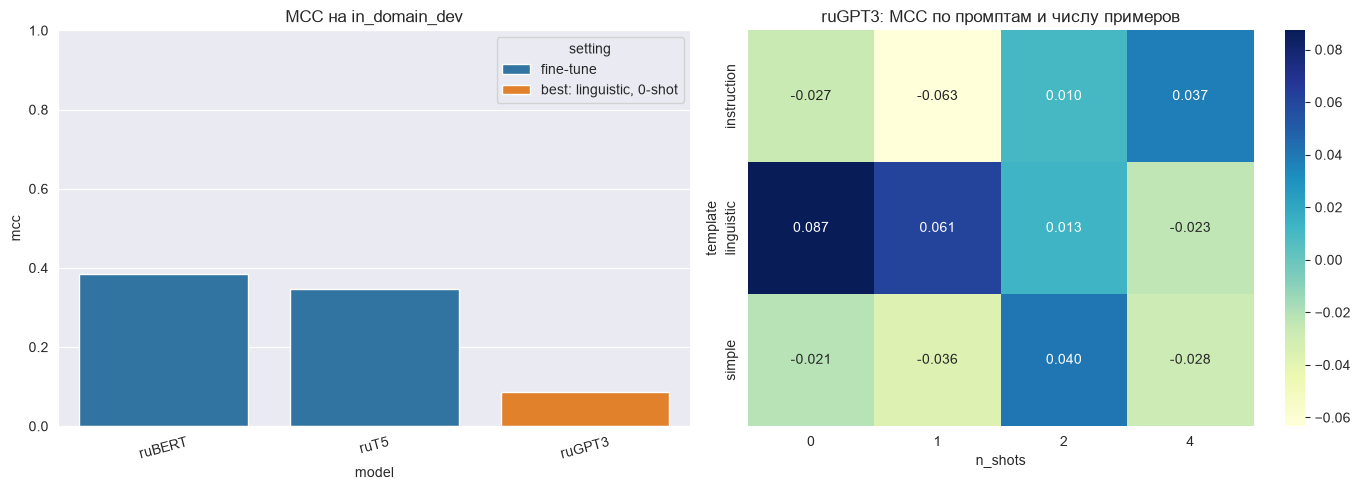

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = summary_df[
    summary_df["setting"].isin(["fine-tune"]) | summary_df["setting"].str.startswith("best")
]
sns.barplot(data=plot_df, x="model", y="mcc", hue="setting", ax=axes[0])
axes[0].set_title("MCC на in_domain_dev")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

gpt_pivot = gpt_results_df.pivot(index="template", columns="n_shots", values="mcc")
sns.heatmap(gpt_pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("ruGPT3: MCC по промптам и числу примеров")

plt.tight_layout()
plt.show()
